# Citations:

In [1]:
# @Misc{devos2015,
  #author = {Nelis J. de Vos},
  # title = {kmodes categorical clustering library},
  # howpublished = {\url{https://github.com/nicodv/kmodes}},
  # year = {2015--2021}
# }

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 8)
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from kmodes.kmodes import KModes
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import make_scorer
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn import metrics
from sklearn.utils import resample

# Data Reading and Exploration

In [3]:
fen_df = pd.read_csv('Updated.csv')
fen_df.shape

(72236, 33)

In [4]:
for col in fen_df.select_dtypes(include=np.number).columns:
    fen_df.fillna({col: 0}, inplace=True)

for col in fen_df.select_dtypes(exclude=np.number).columns:
    fen_df.fillna({col: 'Unknown'}, inplace=True)

In [5]:
fen_df.isnull().sum().sum()

np.int64(0)

In [6]:
#Dropping Age code because they are all 1. Dropping Year because they are all 2021
fen_df = fen_df.drop(['AgeCode', 'Year'], axis=1)

In [7]:
col_999 = fen_df.loc[fen_df['Age'] == 999, ['Race', 'Education', 'Death']]
print(col_999)

          Race Education                        Death
2798     White   Unknown    Accidental Drug Poisoning
4499     White   Unknown    Accidental Drug Poisoning
5040     White   Unknown    Accidental Drug Poisoning
5988     White   Unknown    Accidental Drug Poisoning
7749   Chinese   Unknown    Accidental Drug Poisoning
9551     White   Unknown    Accidental Drug Poisoning
9576     White   Unknown    Accidental Drug Poisoning
18021    White   Unknown    Accidental Drug Poisoning
21274    White   Unknown    Accidental Drug Poisoning
21888    White   Unknown    Accidental Drug Poisoning
32896    White   Unknown  Undetermined Drug Poisoning
45222    White   Unknown    Accidental Drug Poisoning
53320    White   Unknown       Suicide Drug Poisoning


In [8]:
#Remove Age 999 as most of their information was unknown
fen_df = fen_df[fen_df['Age'] <= 150]

In [9]:
#Checking the highest age in the dataframe
fen_df['Age'].max()

np.int64(98)

In [10]:
#Describing the columns
columns = fen_df.columns
for c in columns:
    print('****', c, '****')
    print(fen_df[c].describe())

**** Education ****
count                                     72223
unique                                        9
top       High school graduate or GED completed
freq                                      37015
Name: Education, dtype: object
**** Month of Death ****
count     72223
unique       12
top       April
freq       6397
Name: Month of Death, dtype: object
**** Sex ****
count     72223
unique        2
top           M
freq      52195
Name: Sex, dtype: object
**** Age ****
count    72223.000000
mean        41.308157
std         12.977409
min          1.000000
25%         31.000000
50%         40.000000
75%         51.000000
max         98.000000
Name: Age, dtype: float64
**** AgeCategory ****
count             72223
unique               24
top       30 - 34 years
freq              10722
Name: AgeCategory, dtype: object
**** Marital Status ****
count                     72223
unique                        5
top       Never married, single
freq                      43313
Name: Mar

In [11]:
fen_df.groupby("Education").size().sort_values()

Education
Doctorate or professional degree           193
Masters degree                             564
Unknown                                   2298
8th grade or less                         2347
Bachelors degree                          3348
Associate degree                          3617
Some college credit, but no degree       10225
9 - 12th grade, no diploma               12616
High school graduate or GED completed    37015
dtype: int64

In [12]:
fen_df.groupby("Race").size().sort_values()

Race
AIAN and NHOPI                                                     1
AIAN, Asian and White                                              2
Black, AIAN and Asian                                              2
Black, Asian and NHOPI                                             2
Black, Asian and White                                             6
Guamanian                                                          9
Black and Native Hawaiian or Other Pacific Islander (NHOPI)        9
Asian and NHOPI                                                   10
AIAN and Asian                                                    14
Asian, NHOPI and White                                            14
Black and Asian                                                   19
Black, AIAN and White                                             20
Hawaiian                                                          20
Japanese                                                          20
Samoan                       

In [13]:
#Group all mixed in 1 category and put Asians in 1 category and others in 1 category. We are using a mapping function for this task
def fixrace(race):
    mixed = ['AIAN, Asian, NHOPI and White', 'Black, AIAN, NHOPI and White', 'AIAN and NHOPI',
                 'Black, NHOPI and White', 'Black, Asian and NHOPI', 'Black, AIAN, Asian and White',
                 'Black, AIAN and Asian', 'AIAN, Asian and White', 'Black, Asian and White',
                 'Black and Native Hawaiian or Other Pacific Islander (NHOPI)', 'AIAN and Asian',
                 'Black, AIAN and White', 'Black and Asian', 'Asian and NHOPI', 'Asian, NHOPI and White',
                 'NHOPI and White', 'Black and AIAN', 'Asian and White', 'AIAN and White', 'Black and White']
    asian = ['Japanese', 'Chinese', 'Korean', 'Vietnamese', 'Asian Indian', 'Filipino', 'Other or Multiple Asian']
    other = ['Guamanian', 'Samoan', 'Hawaiian', 'Other or Multiple Pacific Islander', 'American Indian or Alaskan Native (AIAN)']

    if race in mixed:
        return 'Mixed'
    elif race in asian:
        return 'Asian'
    elif race in other:
        return 'Other/ Islanders'
    else:
        return race

In [14]:
fen_df['Race'] = fen_df['Race'].apply(fixrace)

In [15]:
fen_df.groupby("Race").size().sort_values()

Race
Asian                 525
Mixed                 987
Other/ Islanders      993
Black               14277
White               55441
dtype: int64

In [16]:
fen_df.head()

,Education,Month of Death,Sex,Age,AgeCategory,Marital Status,Manner of Death,Race,Occupation,Death,...,Condition11,Condition12,Condition13,Condition14,Condition15,Condition16,Condition17,Condition18,Condition19,Condition20
0,"Some college credit, but no degree",January,M,62,60 - 64 years,Divorced,Accident,Other/ Islanders,Management Occupations,Accidental Drug Poisoning,...,Unknown,Unknown,Unknown,Unknown,0.0,0.0,0.0,0.0,0.0,0.0
1,"9 - 12th grade, no diploma",January,M,17,15 - 19 years,"Never married, single",Accident,White,"Other, Misc (exc Housewife)",Accidental Drug Poisoning,...,Unknown,Unknown,Unknown,Unknown,0.0,0.0,0.0,0.0,0.0,0.0
2,"Some college credit, but no degree",January,M,35,35 - 39 years,"Never married, single",Accident,White,Management Occupations,Accidental Drug Poisoning,...,Unknown,Unknown,Unknown,Unknown,0.0,0.0,0.0,0.0,0.0,0.0
3,High school graduate or GED completed,January,M,30,30 - 34 years,"Never married, single",Accident,Other/ Islanders,"Farming, Fishing, & Forestry Occupations",Accidental Drug Poisoning,...,Unknown,Unknown,Unknown,Unknown,0.0,0.0,0.0,0.0,0.0,0.0
4,8th grade or less,January,M,68,65 - 69 years,Divorced,Accident,White,Management Occupations,Accidental Drug Poisoning,...,Unknown,Unknown,Unknown,Unknown,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
print(fen_df['Age'].describe())

age_labels = ['18 and under', '19 to 30', '31 to 40', '41 to 50', '51 to 65', '65 and up']

age_bins = [0, 18, 30, 40, 50, 65, 100]

fen_df['AgeCategory'] = pd.cut(fen_df['Age'], bins=age_bins, labels=age_labels, right=True)

count    72223.000000
mean        41.308157
std         12.977409
min          1.000000
25%         31.000000
50%         40.000000
75%         51.000000
max         98.000000
Name: Age, dtype: float64


In [18]:
fen_df.head()

,Education,Month of Death,Sex,Age,AgeCategory,Marital Status,Manner of Death,Race,Occupation,Death,...,Condition11,Condition12,Condition13,Condition14,Condition15,Condition16,Condition17,Condition18,Condition19,Condition20
0,"Some college credit, but no degree",January,M,62,51 to 65,Divorced,Accident,Other/ Islanders,Management Occupations,Accidental Drug Poisoning,...,Unknown,Unknown,Unknown,Unknown,0.0,0.0,0.0,0.0,0.0,0.0
1,"9 - 12th grade, no diploma",January,M,17,18 and under,"Never married, single",Accident,White,"Other, Misc (exc Housewife)",Accidental Drug Poisoning,...,Unknown,Unknown,Unknown,Unknown,0.0,0.0,0.0,0.0,0.0,0.0
2,"Some college credit, but no degree",January,M,35,31 to 40,"Never married, single",Accident,White,Management Occupations,Accidental Drug Poisoning,...,Unknown,Unknown,Unknown,Unknown,0.0,0.0,0.0,0.0,0.0,0.0
3,High school graduate or GED completed,January,M,30,19 to 30,"Never married, single",Accident,Other/ Islanders,"Farming, Fishing, & Forestry Occupations",Accidental Drug Poisoning,...,Unknown,Unknown,Unknown,Unknown,0.0,0.0,0.0,0.0,0.0,0.0
4,8th grade or less,January,M,68,65 and up,Divorced,Accident,White,Management Occupations,Accidental Drug Poisoning,...,Unknown,Unknown,Unknown,Unknown,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
# Changing Undetermined/ Suicide/ Unknown Deaths into 1 type: Other

fen_df['Death'] = fen_df['Death'].replace(['Undetermined Drug Poisoning', 'Suicide Drug Poisoning', 'Unknown'], 'Other')

In [20]:
fen_df['Death'].value_counts()

Death
Accidental Drug Poisoning    67848
Other                         4375
Name: count, dtype: int64

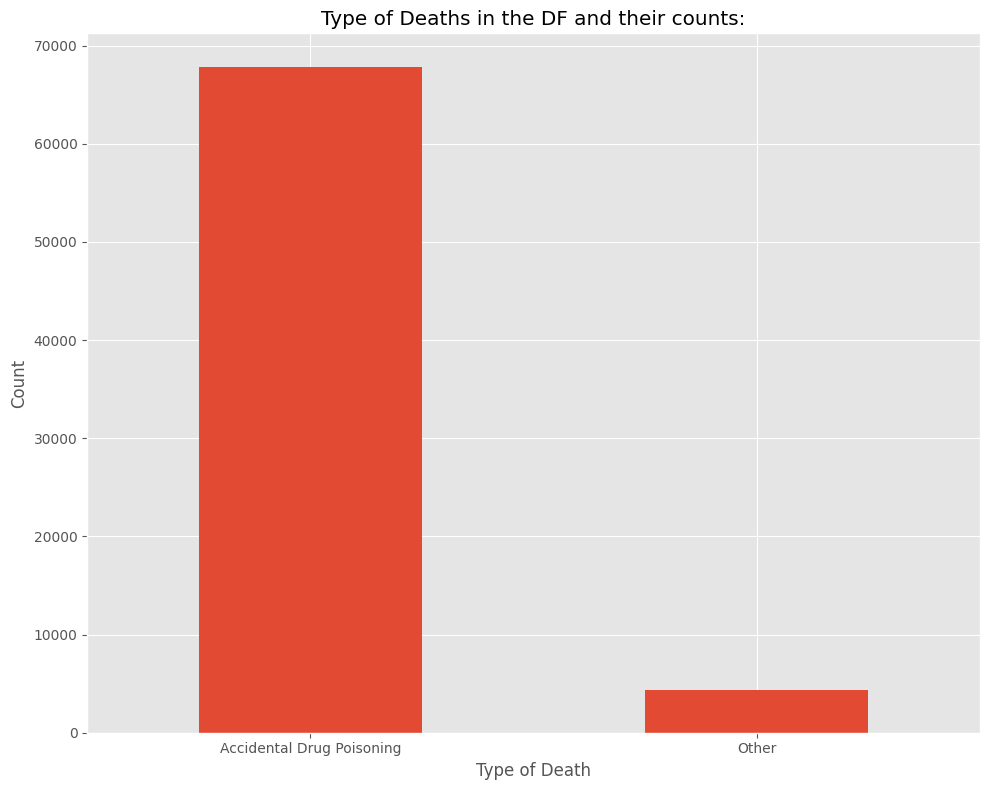

In [21]:
death_count = fen_df['Death'].value_counts()

death_count.plot(kind='bar')
plt.title('Type of Deaths in the DF and their counts:')
plt.xlabel('Type of Death')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
#plt.savefig('TypesofDeathsAccidentalandother.png')

plt.show()

In [22]:
education_count = fen_df['Education'].value_counts()
height = education_count.values
bars = ('H.S. Diploma/GED', '9th-12th No Diploma', 'Some College', 'Associate Degree', 'Bachelors Degree', 
        '8th grade or less', 'Unknown', 'Masters Degree', 'PHD')

print(height)

[37015 12616 10225  3617  3348  2347  2298   564   193]


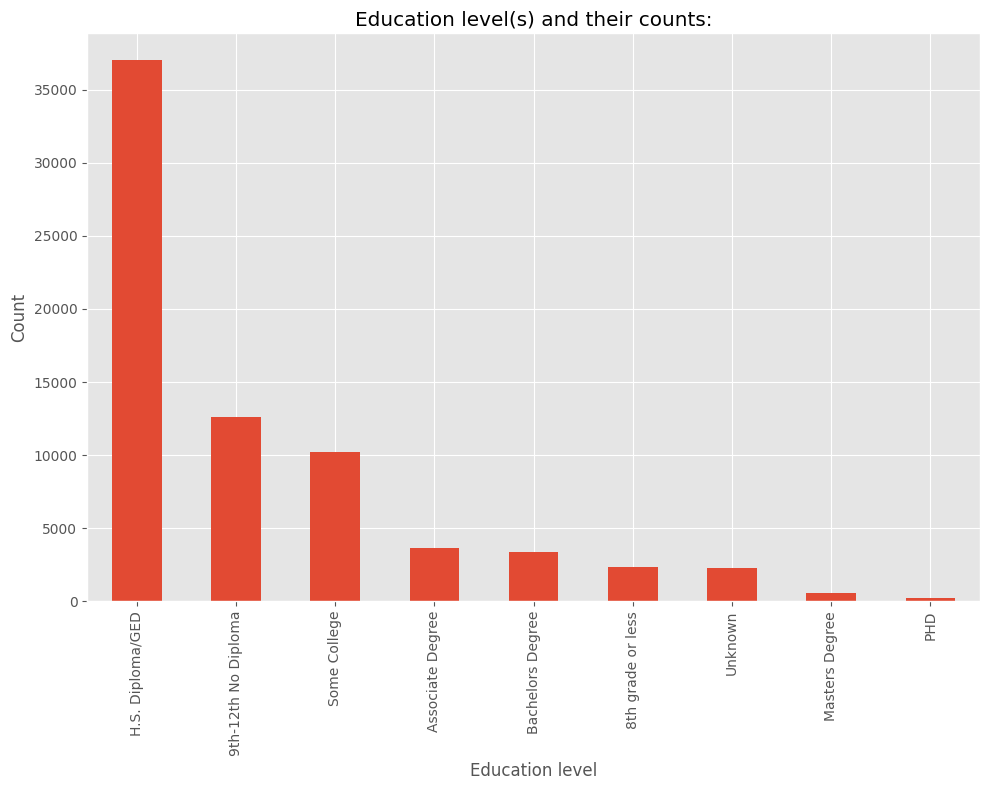

In [23]:
education_count.plot(kind='bar')
plt.title('Education level(s) and their counts:')
plt.xlabel('Education level')
plt.xticks(ticks = np.arange(len(height)), labels=bars)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [24]:
fen_df.to_csv('fen_df.csv')